# Step 4 — Lead-Lag Analysis: Does the Constitutional Gap Predict Democratic Decline?

**Research question:** Does a widening gap between constitutional promise and democratic
reality today predict further democratic change in the future?

**Design:**
- Re-generate OOF gap for all country-years using 5-fold country-blocked CV
- Construct future V-Dem changes at lags k = 1, 2, 3, 4, 5 years
- **CatBoost** model for each lag: predicts Δv2x_polyarchy(t+k) from gap(t) + v2x_polyarchy(t)
  using 5-fold country-blocked CV → honest OOF R² per lag
- SHAP beeswarm + dependence plot to reveal the **shape** of the gap effect
  (linear? threshold? asymmetric?)
- Binned scatter and backsliding episode validation

**Input:** `ccpc_axis_scores_llm.csv` + `vdem/vdem_data.csv`  
**Output:** `lead_lag_catboost.csv`, `episode_validation.csv`

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

/Users/rishithhakker/miniforge3/envs/qss20/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


In [2]:
SCORES_PATH  = 'ccpc_axis_scores_llm.csv'
VDEM_PATH    = 'data/vdem/vdem_data.csv'
TARGET       = 'v2x_polyarchy'
K            = 5
RANDOM_STATE = 42
LAGS         = [1, 2, 3, 4, 5]
SPOTLIGHT    = ['Hungary', 'Turkey', 'Venezuela', 'Poland', 'Brazil', 'India']

FEATURES = [
    'ccpc_civil_liberties', 'ccpc_socioeconomic_rights',
    'ccpc_political_competition', 'ccpc_legislative_autonomy',
    'ccpc_executive_constraints', 'ccpc_judicial_independence',
    'ccpc_rule_of_law_due_process', 'ccpc_institutional_accountability',
    'ccpc_emergency_powers_constraints', 'ccpc_civilian_control_of_security',
    'ccpc_amendment_rigidity', 'ccpc_federalism_decentralization',
    'ccpc_transparency_information_access', 'ccpc_equality_gender_minority_indigenous',
]

# Features fed to the lead-lag CatBoost models
LAG_FEATURES = ['gap', 'v2x_polyarchy']

print(f'Lags: {LAGS}  |  Lag model features: {LAG_FEATURES}')

Lags: [1, 2, 3, 4, 5]  |  Lag model features: ['gap', 'v2x_polyarchy']


## 1 — Load Data & Generate OOF Gap (all years)

In [3]:
ccpc = pd.read_csv(SCORES_PATH)
ccpc['cowcode'] = pd.to_numeric(ccpc['cowcode'], errors='coerce').astype('Int64')
ccpc['year']    = pd.to_numeric(ccpc['year'],    errors='coerce').astype('Int64')

vdem = pd.read_csv(VDEM_PATH, usecols=['country_name', 'country_text_id', 'COWcode', 'year', 'v2x_polyarchy'])
vdem['COWcode'] = pd.to_numeric(vdem['COWcode'], errors='coerce').astype('Int64')

df = vdem.merge(
    ccpc[['cowcode', 'year'] + FEATURES],
    left_on=['COWcode', 'year'], right_on=['cowcode', 'year'],
    how='inner'
).drop(columns=['cowcode'])

df = df.dropna(subset=[TARGET])
df = df.dropna(subset=FEATURES, how='all')
df = df.reset_index(drop=True)

print(f'Rows: {len(df):,} | Countries: {df["COWcode"].nunique()} | Years: {df["year"].min()}–{df["year"].max()}')

Rows: 13,208 | Countries: 178 | Years: 1789–2023


In [4]:
gkf       = GroupKFold(n_splits=K)
groups    = df['COWcode'].values
oof_preds = np.full(len(df), np.nan)

for fold, (train_idx, test_idx) in enumerate(gkf.split(df, groups=groups)):
    m = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=2, l2_leaf_reg=5,
        loss_function='RMSE', random_seed=RANDOM_STATE,
        verbose=0, early_stopping_rounds=30,
    )
    m.fit(
        df.iloc[train_idx][FEATURES], df.iloc[train_idx][TARGET],
        eval_set=(df.iloc[test_idx][FEATURES], df.iloc[test_idx][TARGET]),
    )
    oof_preds[test_idx] = m.predict(df.iloc[test_idx][FEATURES])
    print(f'Fold {fold+1} done')

df['pred'] = np.clip(oof_preds, 0, 1)
df['gap']  = df[TARGET] - df['pred']

print(f'\nOOF R²: {r2_score(df[TARGET], df["pred"]):.4f}')
print(f'Gap range: {df["gap"].min():.3f} – {df["gap"].max():.3f}')

Fold 1 done


Fold 2 done


Fold 3 done


Fold 4 done


Fold 5 done

OOF R²: 0.1027
Gap range: -0.557 – 0.615


## 2 — Gap Trajectories for Selected Countries

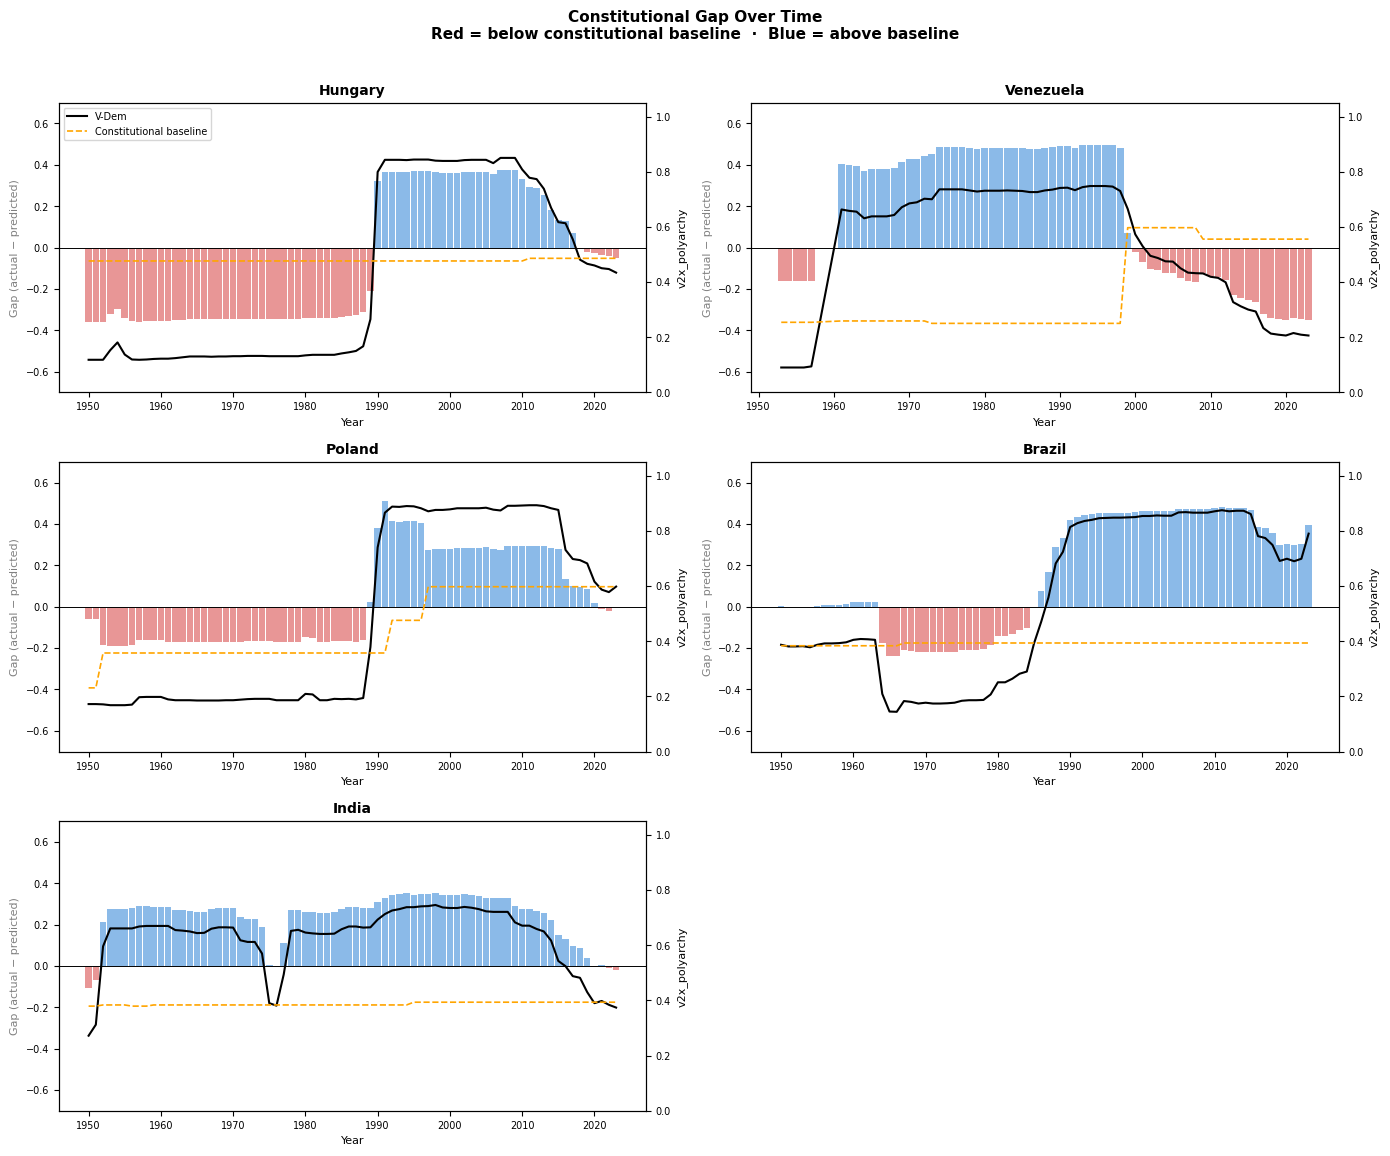

In [5]:
available = [c for c in SPOTLIGHT if c in df['country_name'].values]
ncols = 2
nrows = (len(available) + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.8))
axes = axes.flatten()

for i, country in enumerate(available):
    sub = df[(df['country_name'] == country) & (df['year'] >= 1950)].sort_values('year')

    ax1 = axes[i]
    ax2 = ax1.twinx()

    colors = ['#d32f2f' if g < 0 else '#1976d2' for g in sub['gap']]
    ax1.bar(sub['year'], sub['gap'], color=colors, alpha=0.5, width=0.9, zorder=2)
    ax1.axhline(0, color='black', linewidth=0.7, zorder=3)
    ax1.set_ylabel('Gap (actual − predicted)', fontsize=8, color='grey')
    ax1.set_ylim(-0.7, 0.7)
    ax1.tick_params(axis='y', labelsize=7)

    ax2.plot(sub['year'], sub[TARGET], color='black', linewidth=1.5, zorder=4, label='V-Dem')
    ax2.plot(sub['year'], sub['pred'],  color='orange', linewidth=1.2,
             linestyle='--', zorder=4, label='Constitutional baseline')
    ax2.set_ylabel('v2x_polyarchy', fontsize=8)
    ax2.set_ylim(0, 1.05)
    ax2.tick_params(axis='y', labelsize=7)

    ax1.set_title(country, fontsize=10, fontweight='bold')
    ax1.set_xlabel('Year', fontsize=8)
    ax1.tick_params(axis='x', labelsize=7)
    if i == 0:
        ax2.legend(fontsize=7, loc='upper left')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Constitutional Gap Over Time\n'
    'Red = below constitutional baseline  ·  Blue = above baseline',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## 3 — Construct Lead-Lag Variables

In [6]:
df = df.sort_values(['COWcode', 'year']).reset_index(drop=True)

for k in LAGS:
    future = df.groupby('COWcode')[TARGET].shift(-k)
    df[f'delta_{k}'] = future - df[TARGET]

print('Future delta columns constructed:')
for k in LAGS:
    n = df[f'delta_{k}'].notna().sum()
    print(f'  delta_{k}: {n:,} valid rows  '
          f'(mean={df[f"delta_{k}"].mean():.4f}, std={df[f"delta_{k}"].std():.4f})')

Future delta columns constructed:
  delta_1: 13,030 valid rows  (mean=0.0032, std=0.0434)
  delta_2: 12,852 valid rows  (mean=0.0060, std=0.0652)
  delta_3: 12,674 valid rows  (mean=0.0089, std=0.0805)
  delta_4: 12,496 valid rows  (mean=0.0120, std=0.0927)
  delta_5: 12,318 valid rows  (mean=0.0151, std=0.1035)


## 4 — CatBoost Lead-Lag Models

For each lag k, train a CatBoost model predicting Δv2x_polyarchy(t+k) from
`[gap(t), v2x_polyarchy(t)]` using 5-fold country-blocked CV.

- **gap(t)**: the constitutional gap — the variable of interest
- **v2x_polyarchy(t)**: current democracy level — controls for mean-reversion from level
  (very high democracies are stable; there is more room to fall than to rise)

OOF R² is computed from predictions generated only on held-out countries,
so there is no leakage.

In [7]:
lag_results  = {}   # k → {oof_r2, oof_preds, model, sub_df}
final_models = {}   # k → final model trained on all data (for SHAP)

print(f'{"Lag":>4}  {"OOF R²":>8}  {"N":>7}')
print('-' * 26)

for k in LAGS:
    dep = f'delta_{k}'
    sub = df[df[dep].notna()][['COWcode'] + LAG_FEATURES + [dep]].dropna().copy()
    sub = sub.reset_index(drop=True)

    grps      = sub['COWcode'].values
    X         = sub[LAG_FEATURES].values
    y         = sub[dep].values
    oof       = np.full(len(sub), np.nan)

    for _, (tr_idx, te_idx) in enumerate(GroupKFold(n_splits=K).split(sub, groups=grps)):
        m = CatBoostRegressor(
            iterations=500, learning_rate=0.05, depth=4, l2_leaf_reg=5,
            loss_function='RMSE', random_seed=RANDOM_STATE,
            verbose=0, early_stopping_rounds=20,
        )
        m.fit(X[tr_idx], y[tr_idx],
              eval_set=(X[te_idx], y[te_idx]))
        oof[te_idx] = m.predict(X[te_idx])

    oof_r2 = r2_score(y, oof)
    lag_results[k] = {'oof_r2': oof_r2, 'oof_preds': oof, 'sub': sub}
    print(f'{k:>4}  {oof_r2:>8.4f}  {len(sub):>7,}')

    # Final model on all data for SHAP
    fm = CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=4, l2_leaf_reg=5,
        loss_function='RMSE', random_seed=RANDOM_STATE, verbose=0,
    )
    fm.fit(X, y)
    final_models[k] = fm

print('\nDone.')

 Lag    OOF R²        N
--------------------------


   1    0.0061   13,030


   2    0.0142   12,852


   3    0.0219   12,674


   4    0.0282   12,496


   5    0.0346   12,318



Done.


## 5 — R² Across Lags

How much of future democratic change can the constitutional gap explain,
and does predictive power grow or decay with the horizon?

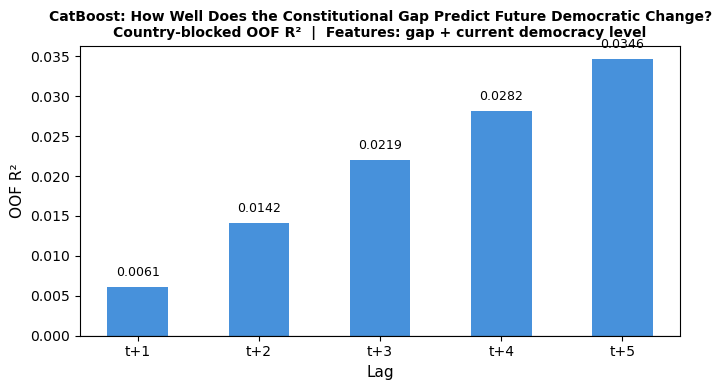

In [8]:
lags   = list(lag_results.keys())
r2s    = [lag_results[k]['oof_r2'] for k in lags]

fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = ['#1976d2' if r > 0 else '#d32f2f' for r in r2s]
bars = ax.bar([f't+{k}' for k in lags], r2s, color=bar_colors, alpha=0.8, width=0.5)

for bar, r2 in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{r2:.4f}', ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Lag', fontsize=11)
ax.set_ylabel('OOF R²', fontsize=11)
ax.set_title(
    'CatBoost: How Well Does the Constitutional Gap Predict Future Democratic Change?\n'
    'Country-blocked OOF R²  |  Features: gap + current democracy level',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 6 — SHAP Beeswarm (Lag 3)

SHAP values show how each feature pushes the prediction above or below the
baseline for every observation. Lag 3 (3-year horizon) is used as the
primary horizon — long enough to capture structural trends, short enough
to be actionable.

- **High gap (blue)** → country is MORE democratic than constitution predicts
- **Low gap (red)** → country is LESS democratic than constitution predicts
- SHAP value direction shows whether those countries tend to improve or decline

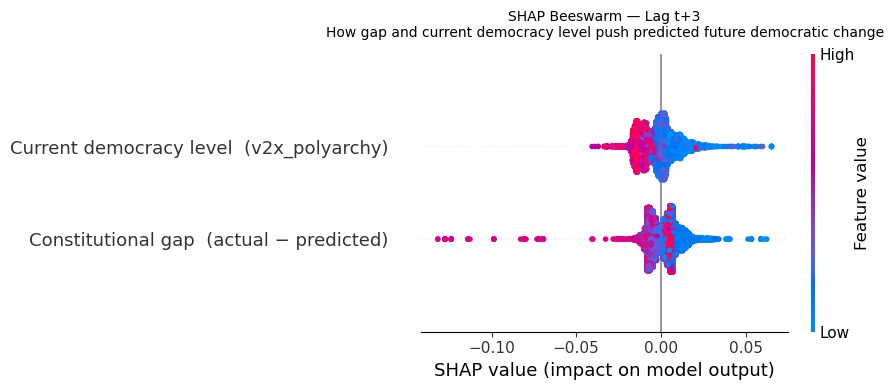

In [9]:
FOCAL_LAG = 3

focal_model = final_models[FOCAL_LAG]
focal_sub   = lag_results[FOCAL_LAG]['sub']
X_focal     = focal_sub[LAG_FEATURES]

explainer  = shap.TreeExplainer(focal_model)
shap_vals  = explainer.shap_values(X_focal)

feature_labels = {
    'gap':           'Constitutional gap  (actual − predicted)',
    'v2x_polyarchy': 'Current democracy level  (v2x_polyarchy)',
}

plt.figure(figsize=(9, 4))
shap.summary_plot(
    shap_vals,
    X_focal.rename(columns=feature_labels),
    feature_names=[feature_labels[f] for f in LAG_FEATURES],
    show=False,
    plot_size=(9, 4),
)
plt.title(
    f'SHAP Beeswarm — Lag t+{FOCAL_LAG}\n'
    'How gap and current democracy level push predicted future democratic change',
    fontsize=10, pad=12
)
plt.tight_layout()
plt.show()

## 7 — SHAP Dependence Plot: Shape of the Gap Effect

The key advantage of CatBoost over OLS: we can see the **exact shape** of
the relationship between the gap and future democratic change.

- A straight line = OLS was right, the effect is linear
- An S-curve or threshold = the effect is non-linear (e.g. only large gaps matter)
- Asymmetry = the model treats positive and negative gaps differently

Shown for all five lags side-by-side.

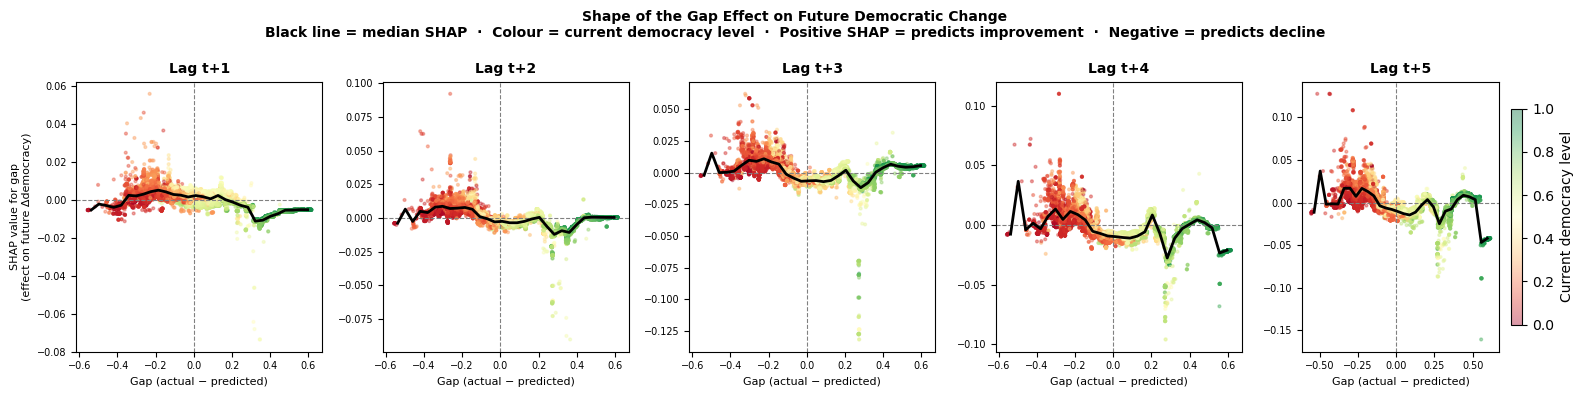

In [10]:
fig, axes = plt.subplots(1, len(LAGS), figsize=(16, 4), sharey=False)

for ax, k in zip(axes, LAGS):
    model_k = final_models[k]
    sub_k   = lag_results[k]['sub']
    X_k     = sub_k[LAG_FEATURES].values

    exp_k   = shap.TreeExplainer(model_k)
    sv_k    = exp_k.shap_values(X_k)

    gap_vals  = X_k[:, 0]        # gap is first feature
    shap_gap  = sv_k[:, 0]       # SHAP values for gap
    vdem_vals = X_k[:, 1]        # colour by current democracy level

    sc = ax.scatter(gap_vals, shap_gap, c=vdem_vals,
                    cmap='RdYlGn', vmin=0, vmax=1,
                    s=4, alpha=0.4, rasterized=True)

    # Smooth trend line
    order   = np.argsort(gap_vals)
    from numpy.polynomial.polynomial import polyfit
    smooth_x = np.linspace(gap_vals.min(), gap_vals.max(), 200)
    # Use a rolling median for the trend (non-parametric)
    bins     = pd.cut(gap_vals, bins=30)
    trend    = pd.Series(shap_gap).groupby(bins).median()
    bin_mids = np.array([b.mid for b in trend.index])
    ax.plot(bin_mids, trend.values, color='black', linewidth=2, zorder=5)

    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
    ax.set_title(f'Lag t+{k}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Gap (actual − predicted)', fontsize=8)
    if k == LAGS[0]:
        ax.set_ylabel('SHAP value for gap\n(effect on future Δdemocracy)', fontsize=8)
    ax.tick_params(labelsize=7)

plt.colorbar(sc, ax=axes[-1], label='Current democracy level', shrink=0.8)

fig.suptitle(
    'Shape of the Gap Effect on Future Democratic Change\n'
    'Black line = median SHAP  ·  Colour = current democracy level  ·  '
    'Positive SHAP = predicts improvement  ·  Negative = predicts decline',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 8 — Binned Scatter (Intuitive View)

Divide country-years into five gap quintiles and show the average future
V-Dem change per bin — no model assumptions, just raw conditional means.

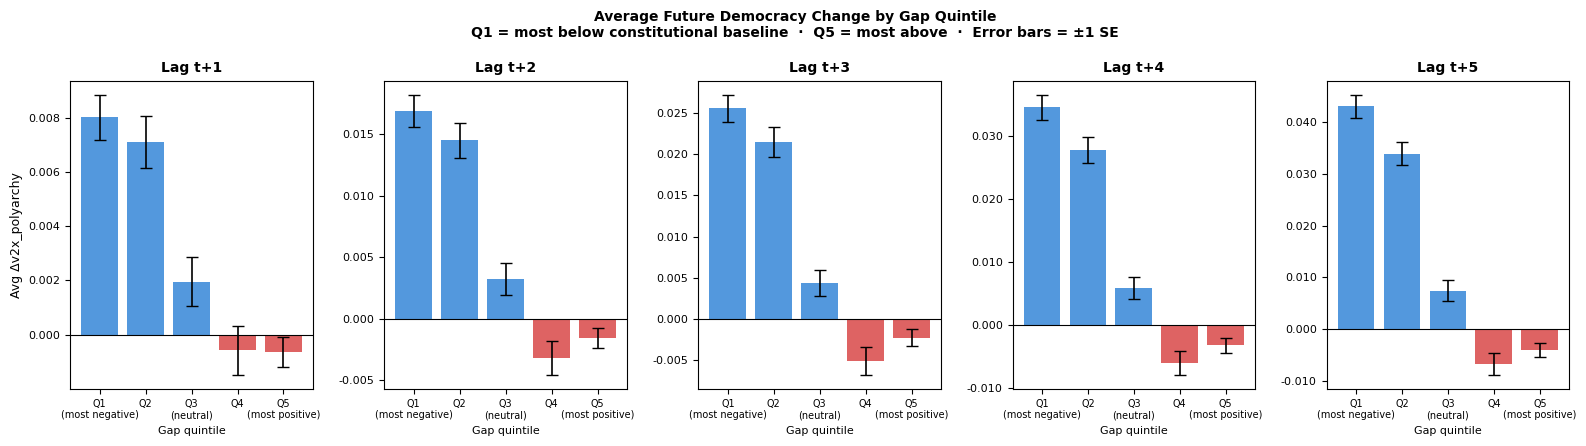

In [11]:
df['gap_quintile'] = pd.qcut(df['gap'], q=5, labels=[
    'Q1\n(most negative)', 'Q2', 'Q3\n(neutral)', 'Q4', 'Q5\n(most positive)'
])

fig, axes = plt.subplots(1, len(LAGS), figsize=(16, 4.5), sharey=False)

for ax, k in zip(axes, LAGS):
    dep   = f'delta_{k}'
    sub   = df[df[dep].notna()]
    means = sub.groupby('gap_quintile')[dep].mean()
    sems  = sub.groupby('gap_quintile')[dep].sem()

    bar_colors = ['#d32f2f' if m < 0 else '#1976d2' for m in means]
    ax.bar(means.index, means.values, yerr=sems.values,
           color=bar_colors, alpha=0.75, capsize=4,
           error_kw={'linewidth': 1.2})
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Lag t+{k}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Gap quintile', fontsize=8)
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=8)
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.3f'))

axes[0].set_ylabel('Avg Δv2x_polyarchy', fontsize=9)
fig.suptitle(
    'Average Future Democracy Change by Gap Quintile\n'
    'Q1 = most below constitutional baseline  ·  Q5 = most above  ·  Error bars = ±1 SE',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 9 — Backsliding Episode Validation

Identify country-years where significant democratic backsliding subsequently occurs
(3-year forward V-Dem decline > 0.05). Check whether the gap was already
negative **before** those episodes — validating it as an early warning signal.

In [12]:
EPISODE_THRESHOLD = 0.05

df['future_3yr'] = df.groupby('COWcode')[TARGET].shift(-3)
df['decline_3yr'] = df[TARGET] - df['future_3yr']
df['episode']    = df['decline_3yr'] > EPISODE_THRESHOLD

print(f'Backsliding episode country-years : {df["episode"].sum():,}')
print(f'Stable / non-backsliding          : {(~df["episode"] & df["decline_3yr"].notna()).sum():,}')

print('\nAverage gap in years BEFORE episode start vs. stable years:')
print(f'{"Lead year":>12}  {"Episode gap":>14}  {"Stable gap":>14}  {"Difference":>12}')
print('-' * 58)

comparison_rows = []
for lead in [0, -1, -2, -3]:
    gap_shifted = df.groupby('COWcode')['gap'].shift(lead)
    label = 't' if lead == 0 else f't{lead}'
    valid = df['decline_3yr'].notna()
    ep_mean  = gap_shifted[df['episode'] & valid].mean()
    nep_mean = gap_shifted[~df['episode'] & valid].mean()
    diff     = ep_mean - nep_mean
    print(f'{label:>12}  {ep_mean:>14.4f}  {nep_mean:>14.4f}  {diff:>+12.4f}')
    comparison_rows.append({'lead': label, 'episode_gap': ep_mean,
                            'nonepisode_gap': nep_mean, 'difference': diff})

print('\n(Negative difference = gap more negative before backsliding episodes)')

Backsliding episode country-years : 874
Stable / non-backsliding          : 11,800

Average gap in years BEFORE episode start vs. stable years:
   Lead year     Episode gap      Stable gap    Difference
----------------------------------------------------------
           t          0.0203          0.0115       +0.0089
         t-1         -0.0193          0.0169       -0.0362
         t-2         -0.0673          0.0224       -0.0897
         t-3         -0.1129          0.0277       -0.1406

(Negative difference = gap more negative before backsliding episodes)


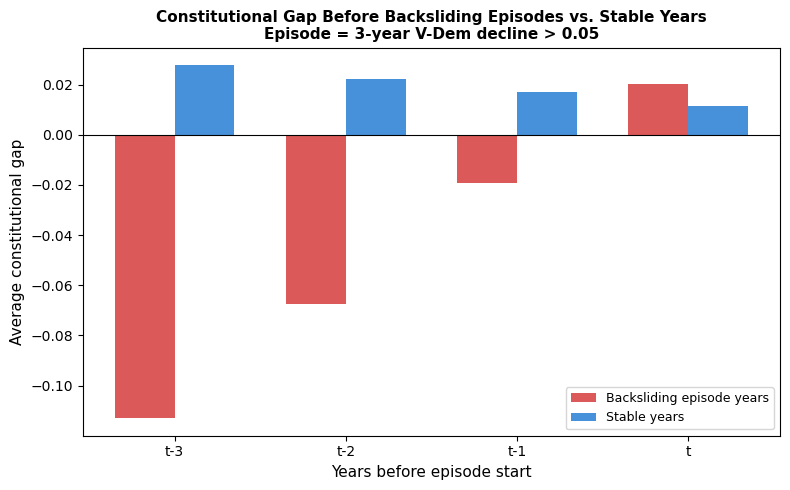

In [13]:
leads    = ['t-3', 't-2', 't-1', 't']
ep_gaps  = [r['episode_gap']    for r in reversed(comparison_rows)]
nep_gaps = [r['nonepisode_gap'] for r in reversed(comparison_rows)]

x, w = np.arange(len(leads)), 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, ep_gaps,  width=w, label='Backsliding episode years',
       color='#d32f2f', alpha=0.8)
ax.bar(x + w/2, nep_gaps, width=w, label='Stable years',
       color='#1976d2', alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(leads, fontsize=10)
ax.set_xlabel('Years before episode start', fontsize=11)
ax.set_ylabel('Average constitutional gap', fontsize=11)
ax.set_title(
    f'Constitutional Gap Before Backsliding Episodes vs. Stable Years\n'
    f'Episode = 3-year V-Dem decline > {EPISODE_THRESHOLD}',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 10 — How Does the Gap Close? Decomposing Baseline Drop vs. Democratic Improvement

Mean reversion could happen two ways:
- **From above**: actual democracy improves (Δv2x_polyarchy > 0) — genuine recovery
- **From below**: the constitutional baseline drops (Δpred < 0) — autocrats rewrite the constitution to legitimize what they have already done

We decompose future gap closure into these two channels for each lag, focusing on deeply negative gap countries (bottom quintile). If baseline drops dominate, the constitutional amendment hypothesis is supported.

In [14]:
for k in LAGS:
    future_pred = df.groupby('COWcode')['pred'].shift(-k)
    df[f'delta_pred_{k}'] = future_pred - df['pred']

print('Baseline change variables constructed.')
print(f'\nAverage Δbaseline by lag (all countries):')
for k in LAGS:
    print(f'  t+{k}:  {df[f"delta_pred_{k}"].mean():+.4f}')

Baseline change variables constructed.

Average Δbaseline by lag (all countries):
  t+1:  +0.0010
  t+2:  +0.0020
  t+3:  +0.0031
  t+4:  +0.0041
  t+5:  +0.0051


In [15]:
# Focus on deeply negative gap countries (bottom quintile)
q20 = df['gap'].quantile(0.20)
deep_neg = df[df['gap'] < q20].copy()

print(f'Deep-negative threshold (Q20): {q20:.3f}')
print(f'Country-years in group:        {len(deep_neg):,}')
print()
print(f'{"Lag":>4}  {"Δ democracy":>14}  {"Δ baseline":>14}  {"Which dominates?":>20}')
print('-' * 60)

decomp_rows = []
for k in LAGS:
    sub = deep_neg[[f'delta_{k}', f'delta_pred_{k}']].dropna()
    d_vdem = sub[f'delta_{k}'].mean()
    d_pred = sub[f'delta_pred_{k}'].mean()
    dominant = 'Amendment ←' if abs(d_pred) > abs(d_vdem) else 'Recovery ←'
    print(f'{k:>4}  {d_vdem:>+14.4f}  {d_pred:>+14.4f}  {dominant:>20}')
    decomp_rows.append({'lag': k, 'delta_vdem': d_vdem, 'delta_baseline': d_pred})

print()
print('Δ democracy  > 0 → actual democracy improved  (gap closes from above)')
print('Δ baseline   < 0 → constitutional baseline dropped  (gap closes from below)')

Deep-negative threshold (Q20): -0.213
Country-years in group:        2,640

 Lag     Δ democracy      Δ baseline      Which dominates?
------------------------------------------------------------
   1         +0.0080         -0.0013            Recovery ←
   2         +0.0170         -0.0021            Recovery ←
   3         +0.0257         -0.0029            Recovery ←
   4         +0.0347         -0.0035            Recovery ←
   5         +0.0429         -0.0040            Recovery ←

Δ democracy  > 0 → actual democracy improved  (gap closes from above)
Δ baseline   < 0 → constitutional baseline dropped  (gap closes from below)


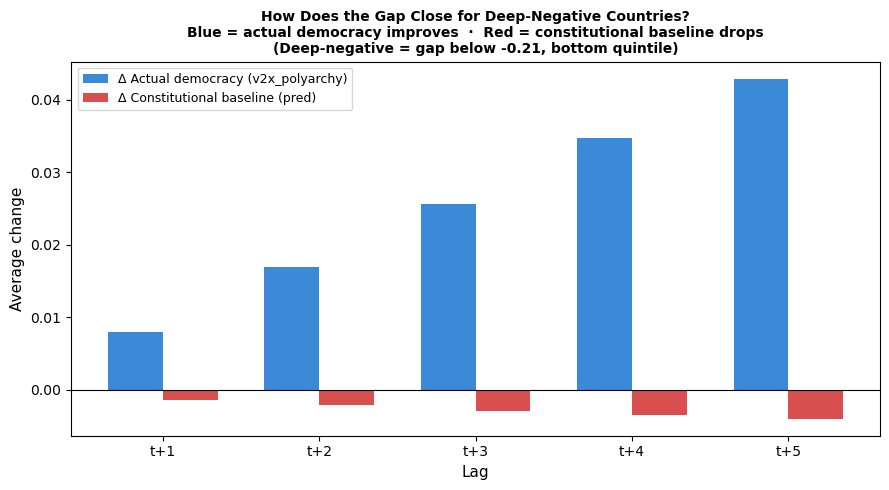

In [16]:
lags_list  = [r['lag']            for r in decomp_rows]
d_vdem_lst = [r['delta_vdem']     for r in decomp_rows]
d_base_lst = [r['delta_baseline'] for r in decomp_rows]

x, w = np.arange(len(lags_list)), 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, d_vdem_lst, width=w, color='#1976d2', alpha=0.85,
       label='Δ Actual democracy (v2x_polyarchy)')
ax.bar(x + w/2, d_base_lst, width=w, color='#d32f2f', alpha=0.85,
       label='Δ Constitutional baseline (pred)')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f't+{k}' for k in lags_list], fontsize=10)
ax.set_xlabel('Lag', fontsize=11)
ax.set_ylabel('Average change', fontsize=11)
ax.set_title(
    'How Does the Gap Close for Deep-Negative Countries?\n'
    'Blue = actual democracy improves  ·  Red = constitutional baseline drops\n'
    f'(Deep-negative = gap below {q20:.2f}, bottom quintile)',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 11 — Decomposition Across All Quintiles (Lag 3)

Repeat for all five gap quintiles to see whether the amendment channel is
specific to deeply backsliding countries or occurs across the board.

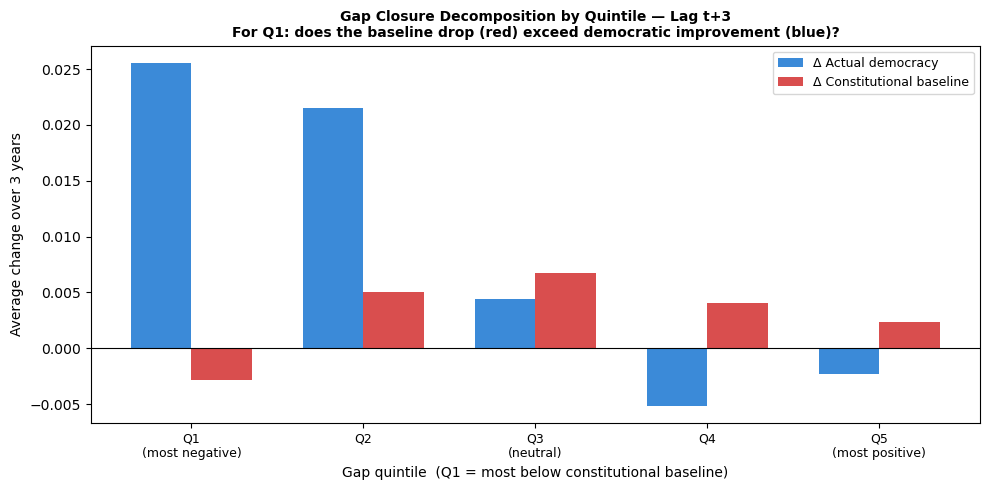


Decomposition table (lag t+3):
              Quintile    Δ democracy    Δ baseline    Amendment dominates?
---------------------------------------------------------------------------
    Q1 (most negative)        +0.0256       -0.0028                      no
                    Q2        +0.0215       +0.0050                      no
          Q3 (neutral)        +0.0044       +0.0067                     YES
                    Q4        -0.0051       +0.0041                      no
    Q5 (most positive)        -0.0023       +0.0024                     YES


In [17]:
DECOMP_LAG = 3

sub = df[['gap_quintile', f'delta_{DECOMP_LAG}', f'delta_pred_{DECOMP_LAG}']].dropna()
vdem_by_q     = sub.groupby('gap_quintile')[f'delta_{DECOMP_LAG}'].mean()
baseline_by_q = sub.groupby('gap_quintile')[f'delta_pred_{DECOMP_LAG}'].mean()

x, w = np.arange(len(vdem_by_q)), 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, vdem_by_q.values,     width=w, color='#1976d2', alpha=0.85,
       label='Δ Actual democracy')
ax.bar(x + w/2, baseline_by_q.values, width=w, color='#d32f2f', alpha=0.85,
       label='Δ Constitutional baseline')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(vdem_by_q.index, fontsize=9)
ax.set_xlabel('Gap quintile  (Q1 = most below constitutional baseline)', fontsize=10)
ax.set_ylabel(f'Average change over {DECOMP_LAG} years', fontsize=10)
ax.set_title(
    f'Gap Closure Decomposition by Quintile — Lag t+{DECOMP_LAG}\n'
    'For Q1: does the baseline drop (red) exceed democratic improvement (blue)?',
    fontsize=10, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'\nDecomposition table (lag t+{DECOMP_LAG}):')
print(f'{"Quintile":>22}  {"Δ democracy":>13}  {"Δ baseline":>12}  {"Amendment dominates?":>22}')
print('-' * 75)
for q, dv, db in zip(vdem_by_q.index, vdem_by_q.values, baseline_by_q.values):
    dominant = 'YES' if abs(db) > abs(dv) else 'no'
    print(f'{str(q).replace(chr(10)," "):>22}  {dv:>+13.4f}  {db:>+12.4f}  {dominant:>22}')

## 10 — Export

In [18]:
lag_table = pd.DataFrame([
    {'lag': k, 'oof_r2': lag_results[k]['oof_r2'], 'n': len(lag_results[k]['sub'])}
    for k in LAGS
])
lag_table.to_csv('outputs/lead_lag_catboost.csv', index=False)

ep_table = pd.DataFrame(comparison_rows)
ep_table.to_csv('outputs/episode_validation.csv', index=False)

decomp_table = pd.DataFrame(decomp_rows)
decomp_table.to_csv('outputs/gap_decomposition.csv', index=False)

print('Exported: lead_lag_catboost.csv, episode_validation.csv, gap_decomposition.csv')
print()
print(lag_table.round(4).to_string(index=False))

Exported: lead_lag_catboost.csv, episode_validation.csv, gap_decomposition.csv

 lag  oof_r2     n
   1  0.0061 13030
   2  0.0142 12852
   3  0.0219 12674
   4  0.0282 12496
   5  0.0346 12318
